In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

# =========================================================
# PARAMETERS
# =========================================================
OIL_COL    = 'Brent'
OVX_COL    = 'OVXCLS'
Z_THRESH   = -2.5     # standardized threshold for jump detection
VOL_WINDOW = 252      # rolling window for daily σ̂
ANN_FACTOR = 52       # annualization for weekly λ

In [17]:
# =========================================================
# 0)  LOAD & PREP
# =========================================================
oil_price = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
ovx       = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')

oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')
ovx['date']       = pd.to_datetime(ovx['date'],       errors='coerce')

df = (pd.merge(oil_price[['date', OIL_COL]], ovx[['date', OVX_COL]],
               on='date', how='inner')
        .sort_values('date')
        .reset_index(drop=True))
df.ffill(inplace=True)

df = df[(df['date']>'2013-01-01') & (df['date']<'2024-12-31')]

C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_35140\2366735977.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')


In [18]:
# =========================================================
# 1)  DAILY RETURNS
# =========================================================
df['log_ret']    = np.log(df[OIL_COL] / df[OIL_COL].shift(1))
df['arith_ret']  = df[OIL_COL] / df[OIL_COL].shift(1) - 1
df['roll_sigma'] = df['log_ret'].rolling(VOL_WINDOW, min_periods=126).std()
df['z_score']    = df['log_ret'] / df['roll_sigma']
df.dropna(subset=['log_ret', 'roll_sigma', OVX_COL], inplace=True)

In [35]:
# =========================================================
# 2)  JUMP DETECTION  —  daily |z-score| > 2.5
# =========================================================
df['jump_daily'] = (np.abs(df['z_score']) > np.abs(Z_THRESH)).astype(int)
df['week']       = df['date'].dt.to_period('W')
jump_weeks_set   = set(df.loc[df['jump_daily'] == 1, 'week'])

print(f"Daily jump observations : {df['jump_daily'].sum()}")
print(f"  Negative jumps: {(df['z_score'] < Z_THRESH).sum()}")
print(f"  Positive jumps: {(df['z_score'] > -Z_THRESH).sum()}")
print(f"Weeks containing a jump : {len(jump_weeks_set)}")

Daily jump observations : 100
  Negative jumps: 60
  Positive jumps: 40
Weeks containing a jump : 74


In [36]:
# =========================================================
# 3)  WEEKLY AGGREGATION
# =========================================================
# oil: last price of the week
oil_weekly = (df.set_index('date')[[OIL_COL]]
                .resample('W-FRI').last()
                .reset_index())
oil_weekly['week_ret'] = oil_weekly[OIL_COL] / oil_weekly[OIL_COL].shift(1) - 1

# OVX: last value of the week
ovx_weekly = (df.set_index('date')[[OVX_COL]]
                .resample('W-FRI').last()
                .reset_index())

df_weekly = pd.merge(oil_weekly, ovx_weekly, on='date', how='inner')
df_weekly['week']         = df_weekly['date'].dt.to_period('W')
df_weekly['is_jump_week'] = df_weekly['week'].isin(jump_weeks_set).astype(int)
df_weekly.dropna(subset=['week_ret', OVX_COL], inplace=True)


Jump week returns — mean: -0.0116  std: 0.0996
N jump weeks: 74
count    74.000000
mean     -0.011639
std       0.099639
min      -0.267998
25%      -0.065404
50%      -0.033857
75%       0.061086
max       0.373997
Name: week_ret, dtype: float64

Normality of weekly jump returns:
  KS test:          stat=0.1175,  p=0.2396
  Shapiro-Wilk:     stat=0.9539,  p=0.0088

Normality of ln(1+J) — Merton (1976) requirement:
  KS test:          stat=0.0998,  p=0.4245
  Shapiro-Wilk:     stat=0.9683,  p=0.0594


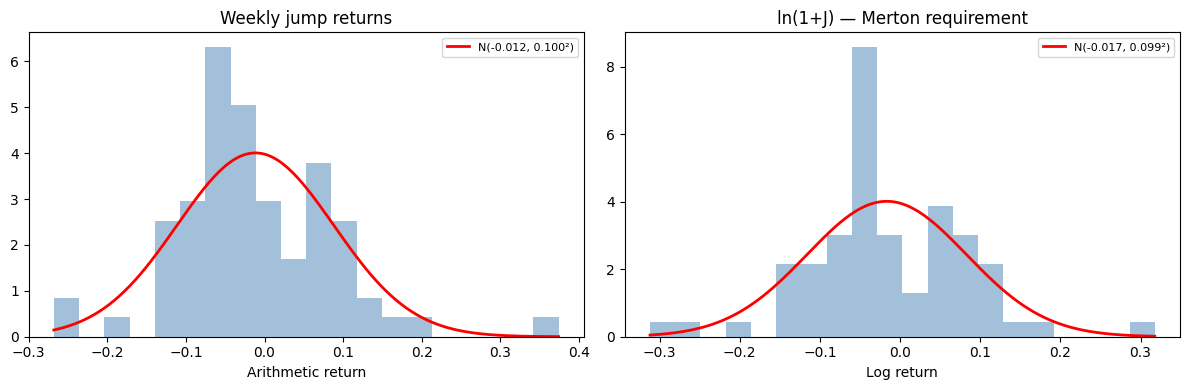


J (mean, all jump weeks): -0.0116
σ_J:                      0.0996


In [37]:
# =========================================================
# 4)  JUMP SIZE DISTRIBUTION  —  all jump weeks
# =========================================================
from scipy.stats import shapiro, kstest, norm as sp_norm

jump_week_returns = df_weekly.loc[df_weekly['is_jump_week'] == 1, 'week_ret']

mu_J    = jump_week_returns.mean()
sigma_J = jump_week_returns.std()

print(f"Jump week returns — mean: {mu_J:.4f}  std: {sigma_J:.4f}")
print(f"N jump weeks: {len(jump_week_returns)}")
print(jump_week_returns.describe())

# test normality of weekly returns directly
ks_stat, ks_p   = kstest(jump_week_returns, 'norm', args=(mu_J, sigma_J))
sw_stat, sw_p   = shapiro(jump_week_returns)

print(f"\nNormality of weekly jump returns:")
print(f"  KS test:          stat={ks_stat:.4f},  p={ks_p:.4f}")
print(f"  Shapiro-Wilk:     stat={sw_stat:.4f},  p={sw_p:.4f}")

# also test ln(1+J) — what Merton (1976) actually requires
log_jump_rets = np.log(1 + jump_week_returns)
mu_logJ    = log_jump_rets.mean()
sigma_logJ = log_jump_rets.std()

ks_log_stat, ks_log_p = kstest(log_jump_rets, 'norm', args=(mu_logJ, sigma_logJ))
sw_log_stat, sw_log_p = shapiro(log_jump_rets)

print(f"\nNormality of ln(1+J) — Merton (1976) requirement:")
print(f"  KS test:          stat={ks_log_stat:.4f},  p={ks_log_p:.4f}")
print(f"  Shapiro-Wilk:     stat={sw_log_stat:.4f},  p={sw_log_p:.4f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(jump_week_returns.min(), jump_week_returns.max(), 200)
axes[0].hist(jump_week_returns, bins=20, density=True, alpha=0.5, color='steelblue')
axes[0].plot(x, sp_norm.pdf(x, mu_J, sigma_J), lw=2, color='red',
             label=f'N({mu_J:.3f}, {sigma_J:.3f}²)')
axes[0].set_title('Weekly jump returns')
axes[0].set_xlabel('Arithmetic return')
axes[0].legend(fontsize=8)

x2 = np.linspace(log_jump_rets.min(), log_jump_rets.max(), 200)
axes[1].hist(log_jump_rets, bins=20, density=True, alpha=0.5, color='steelblue')
axes[1].plot(x2, sp_norm.pdf(x2, mu_logJ, sigma_logJ), lw=2, color='red',
             label=f'N({mu_logJ:.3f}, {sigma_logJ:.3f}²)')
axes[1].set_title('ln(1+J) — Merton requirement')
axes[1].set_xlabel('Log return')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# keep J as mean for pricer
J = mu_J
print(f"\nJ (mean, all jump weeks): {J:.4f}")
print(f"σ_J:                      {sigma_J:.4f}")

In [44]:
log_jump_rets = np.log(1 + jump_week_returns)
print(f"mu_J    (mean of ln(1+J)): {log_jump_rets.mean():.6f}")
print(f"sigma_J (std  of ln(1+J)): {log_jump_rets.std():.6f}")
print(f"logit_const:    {logit_model.params['const']:.6f}")
print(f"logit_ovx_coef: {logit_model.params[OVX_COL]:.6f}")

mu_J    (mean of ln(1+J)): -0.016617
sigma_J (std  of ln(1+J)): 0.099499
logit_const:    -2.782760
logit_ovx_coef: 0.054707



Exponential fit: θ = 13.5998,  implied mean |J| = 0.0735
Log-normal fit: s=0.7678, scale=0.0569

KS test — exponential : stat=0.2326,   p=0.0127
KS test — log-normal  : stat=0.1030,  p=0.6878


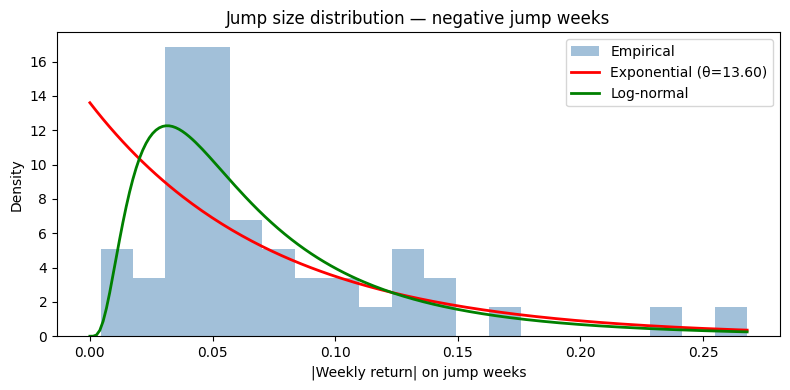


Final J (mean arithmetic, negative jump weeks only): -0.0735
log(1+J): -0.0764


In [38]:
from scipy.stats import expon, lognorm
from scipy.optimize import curve_fit

# =========================================================
# 4b)  JUMP SIZE DISTRIBUTION  —  negative jump weeks only
# =========================================================
neg_jumps = jump_week_returns[jump_week_returns < 0].copy()
J = neg_jumps.mean()   # update J to use filtered sample
abs_jumps = neg_jumps.abs().values  # exponential defined on positive support

# --- fit exponential: f(x) = θ·exp(-θx), mean = 1/θ
theta_mle = 1 / abs_jumps.mean()   # MLE for exponential is 1/sample_mean
print(f"\nExponential fit: θ = {theta_mle:.4f},  implied mean |J| = {1/theta_mle:.4f}")

# --- fit log-normal as alternative
lognorm_params = lognorm.fit(abs_jumps, floc=0)
print(f"Log-normal fit: s={lognorm_params[0]:.4f}, scale={lognorm_params[2]:.4f}")

# --- KS test: which fits better?
from scipy.stats import kstest
ks_exp     = kstest(abs_jumps, 'expon',   args=(0, 1/theta_mle))
ks_lognorm = kstest(abs_jumps, 'lognorm', args=lognorm_params)
print(f"\nKS test — exponential : stat={ks_exp.statistic:.4f},   p={ks_exp.pvalue:.4f}")
print(f"KS test — log-normal  : stat={ks_lognorm.statistic:.4f},  p={ks_lognorm.pvalue:.4f}")

# --- plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(abs_jumps, bins=20, density=True, alpha=0.5, color='steelblue', label='Empirical')
x = np.linspace(0, abs_jumps.max(), 200)
ax.plot(x, expon.pdf(x, scale=1/theta_mle),  lw=2, color='red',    label=f'Exponential (θ={theta_mle:.2f})')
ax.plot(x, lognorm.pdf(x, *lognorm_params),  lw=2, color='green',  label='Log-normal')
ax.set_xlabel('|Weekly return| on jump weeks')
ax.set_ylabel('Density')
ax.set_title('Jump size distribution — negative jump weeks')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal J (mean arithmetic, negative jump weeks only): {J:.4f}")
print(f"log(1+J): {np.log(1+J):.4f}")

In [ ]:
# =========================================================
# 5)  LOGISTIC REGRESSION  —  OVX this week → any jump in next 4 weeks
# =========================================================
# forward 4-week jump indicator: 1 if any jump occurs in weeks t+1 to t+4
df_weekly['jump_next4w'] = (
    df_weekly['is_jump_week']
    .shift(-1)          # exclude current week
    .rolling(4, min_periods=1)
    .max()
    .values
)

# OVX: no lag needed — it's already forward-looking 30 days
df_reg = df_weekly.dropna(subset=[OVX_COL, 'jump_next4w']).copy()

# drop last 4 rows — their forward window is incomplete
df_reg = df_reg.iloc[:-4].copy()

X = sm.add_constant(df_reg[OVX_COL])
y = df_reg['jump_next4w'].astype(int)

logit_model = sm.Logit(y, X).fit(disp=False)
print(logit_model.summary())

print(f"\nBase rate of jump_next4w: {y.mean():.3f}")
print(f"λ at OVX=15:  {ovx_to_lambda(15):.2f}")
print(f"λ at OVX=35:  {ovx_to_lambda(35):.2f}")
print(f"λ at OVX=55:  {ovx_to_lambda(55):.2f}")
print(f"λ at OVX=80:  {ovx_to_lambda(80):.2f}")
print(f"λ at OVX=100: {ovx_to_lambda(100):.2f}")
print(f"λ at OVX=200: {ovx_to_lambda(200):.2f}")

                           Logit Regression Results                           
Dep. Variable:            jump_next4w   No. Observations:                  597
Model:                          Logit   Df Residuals:                      595
Method:                           MLE   Df Model:                            1
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                 0.08813
Time:                        16:42:12   Log-Likelihood:                -345.87
converged:                       True   LL-Null:                       -379.30
Covariance Type:            nonrobust   LLR p-value:                 2.916e-16
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7828      0.318     -8.744      0.000      -3.406      -2.159
OVXCLS         0.0547      0.008      6.842      0.000       0.039       0.070

Base rate of jump_next4w: 0.332
λ at OVX=15:  6.84


In [40]:
# =========================================================
# 7)  EXPORT PARAMETERS
# =========================================================
jump_params = {
    'J'            : J,
    'logit_const'  : logit_model.params['const'],
    'logit_ovx_coef': logit_model.params[OVX_COL]
}

print("\nParameters to pass to M2 pricer:")
for k, v in jump_params.items():
    print(f"  {k:20s}: {v:.6f}")



def ovx_to_lambda(ovx):
    if np.isnan(ovx) or ovx <= 0:
        return 0.0
    logit_p   = logit_model.params['const'] + logit_model.params[OVX_COL] * ovx
    p_hat   = 1 / (1 + np.exp(-logit_p))
    p_hat   = np.clip(p_hat, 1e-8, 1 - 1e-8)   # numerical safety only
    return min(-np.log(1 - p_hat) * 52, 52)


df_reg['lam_annual'] = df_reg[OVX_COL].apply(ovx_to_lambda)


Parameters to pass to M2 pricer:
  J                   : -0.073530
  logit_const         : -2.782760
  logit_ovx_coef      : 0.054707


KeyError: 'lam_annual'

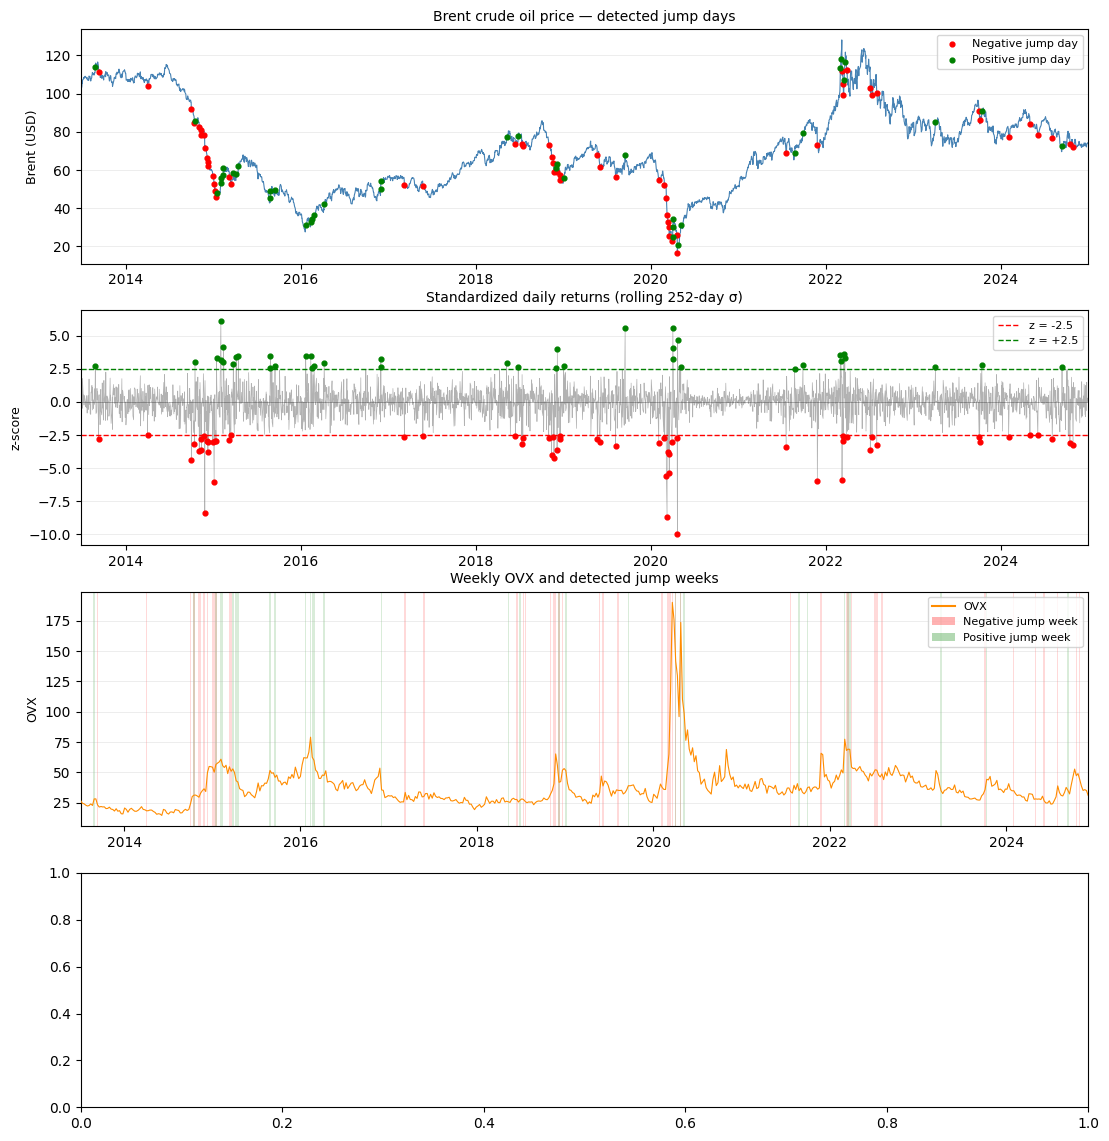

In [45]:
# =========================================================
# 8)  DIAGNOSTIC PLOTS
# =========================================================
fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=False)

date_min = df['date'].min()
date_max = df['date'].max()

# separate positive and negative jump days
neg_jump_days = df[(df['jump_daily'] == 1) & (df['z_score'] < 0)]
pos_jump_days = df[(df['jump_daily'] == 1) & (df['z_score'] > 0)]

# separate positive and negative jump weeks for panel 3
neg_jump_week_dates = set()
pos_jump_week_dates = set()
for _, row in df[df['jump_daily'] == 1].iterrows():
    if row['z_score'] < 0:
        neg_jump_week_dates.add(row['week'])
    else:
        pos_jump_week_dates.add(row['week'])

# ── Panel 1: Oil price with jump days ────────────────────
ax = axes[0]
ax.plot(df['date'], df[OIL_COL], lw=0.8, color='steelblue', zorder=2)
ax.scatter(neg_jump_days['date'], neg_jump_days[OIL_COL],
           color='red',   s=12, zorder=5, label='Negative jump day')
ax.scatter(pos_jump_days['date'], pos_jump_days[OIL_COL],
           color='green', s=12, zorder=5, label='Positive jump day')
ax.set_ylabel('Brent (USD)', fontsize=9)
ax.set_title('Brent crude oil price — detected jump days', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(date_min, date_max)
ax.grid(axis='y', lw=0.4, alpha=0.4)

# ── Panel 2: Daily z-scores ───────────────────────────────
ax = axes[1]
ax.plot(df['date'], df['z_score'], lw=0.5, color='gray', alpha=0.6, zorder=2)
ax.axhline(-abs(Z_THRESH), color='red',   ls='--', lw=1, label=f'z = {Z_THRESH}')
ax.axhline( abs(Z_THRESH), color='green', ls='--', lw=1, label=f'z = +{abs(Z_THRESH)}')
ax.axhline(0, color='black', lw=0.4, alpha=0.4)
ax.scatter(neg_jump_days['date'], neg_jump_days['z_score'],
           color='red',   s=12, zorder=5)
ax.scatter(pos_jump_days['date'], pos_jump_days['z_score'],
           color='green', s=12, zorder=5)
ax.set_ylabel('z-score', fontsize=9)
ax.set_title('Standardized daily returns (rolling 252-day σ)', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(date_min, date_max)
ax.grid(axis='y', lw=0.4, alpha=0.4)

# ── Panel 3: Weekly OVX + jump week flags ─────────────────
ax = axes[2]
ax.plot(df_reg['date'], df_reg[OVX_COL],
        lw=0.8, color='darkorange', zorder=3, label='OVX')

for d in df_reg.loc[df_reg['week'].isin(neg_jump_week_dates), 'date']:
    ax.axvspan(d - pd.Timedelta(days=3), d + pd.Timedelta(days=3),
               color='red', alpha=0.15, lw=0)

for d in df_reg.loc[df_reg['week'].isin(pos_jump_week_dates), 'date']:
    ax.axvspan(d - pd.Timedelta(days=3), d + pd.Timedelta(days=3),
               color='green', alpha=0.15, lw=0)

from matplotlib.patches import Patch
ax.legend(handles=[
    plt.Line2D([0], [0], color='darkorange', lw=1.5, label='OVX'),
    Patch(facecolor='red',   alpha=0.3, label='Negative jump week'),
    Patch(facecolor='green', alpha=0.3, label='Positive jump week'),
], fontsize=8, loc='upper right')

ax.set_ylabel('OVX', fontsize=9)
ax.set_title('Weekly OVX and detected jump weeks', fontsize=10)
ax.set_xlim(df_reg['date'].min(), df_reg['date'].max())
ax.grid(axis='y', lw=0.4, alpha=0.4)

# ── Panel 4: Time-varying λ ───────────────────────────────
ax = axes[3]
ax.plot(df_reg['date'], df_reg['lam_annual'],
        lw=0.8, color='purple', zorder=3)
ax.axhline(df_reg['lam_annual'].mean(), color='purple', ls='--', lw=0.8,
           alpha=0.6, label=f"Mean λ = {df_reg['lam_annual'].mean():.1f}")
ax.fill_between(df_reg['date'], df_reg['lam_annual'],
                df_reg['lam_annual'].mean(),
                where=df_reg['lam_annual'] > df_reg['lam_annual'].mean(),
                color='purple', alpha=0.15)
ax.set_ylabel('λ (annualized)', fontsize=9)
ax.set_title('Time-varying jump intensity derived from OVX logistic regression', fontsize=10)
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(df_reg['date'].min(), df_reg['date'].max())
ax.grid(axis='y', lw=0.4, alpha=0.4)

# ── shared x-formatting ───────────────────────────────────
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), fontsize=8)

plt.tight_layout(h_pad=1.5)
plt.show()